# Sensitivities

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from cr3bp import (
    create_earth_moon_system,
    sweep_4d,
    evaluate,
    file_path,
    analyse_sweep
    )

### Initialize the System / Problem

In [2]:
# Create the Earth-Moon system using the cr3bp module
em = create_earth_moon_system()

In [3]:
# Define the LEO and LMO altitudes in meters
leo_alt_m=463e3
lmo_alt_m=100e3

### Load the Optimals

In [4]:
optimals = np.load(f"{file_path}/optimals_iteration3.npy")
#optimals = np.array([3.9706556509695288, 3.0250041828254846, 0.074609375, 0.7299271700356719])
optimal_theta, optimal_delta_v, optimal_delta_v_angle, optimal_tof = optimals
print(f"Optimal theta: {optimal_theta}")
print(f"Optimal delta_v: {optimal_delta_v}")
print(f"Optimal delta_v_angle: {optimal_delta_v_angle}")
print(f"Optimal tof: {optimal_tof}")

Optimal theta: 3.9836391966759
Optimal delta_v: 3.0260560941828256
Optimal delta_v_angle: 0.10454120498614959
Optimal tof: 0.7745498614958449


In [5]:
constraint, objective = evaluate(em, optimals, leo_alt_m, lmo_alt_m)
print(f"Constraint value: {constraint}")
print(f"Objective value: {objective}")

print(f"Constraint Value in km: {constraint * em.l_star * 1e-3}")
print(f"Objective Value in km/s: {objective * em.v_star * 1e-3}")

Constraint value: 1.3895107773883447e-06
Objective value: 3.885171292500793
Constraint Value in km: 0.5341279428280796
Objective Value in km/s: 3.980472085652485


In [6]:
grid_spacings = [0.00088816,
                 0.00115132,
                 0.00031086,
                 0.00138158]

In [7]:
cache_path = Path(f"{file_path}/sweep_4d_results.npy")

if cache_path.exists():
    print(f"Loading cached sweep...")
    results = pd.DataFrame(
        np.load(cache_path),
        columns=['theta', 'delta_v', 'delta_v_angle', 'tof', 'total_delta_v', 'distance_to_lmo']
    )
else:
    print(f"Computing 4D sweep...")
    results = sweep_4d(
        em, 
        optimal_x0=optimals,
        deltas=grid_spacings,
        n_samples=400000,
        tol=2.6e-6,
        leo_alt_m=leo_alt_m,
        lmo_alt_m=lmo_alt_m,
        seed=42
    )
    np.save(cache_path, results)

Loading cached sweep...


Optimal solution from sweep:
  theta:         3.984350 rad
  delta_v:       3.1002 km/s
  delta_v_angle: 0.104560 rad
  tof:           3.3664 days
  total_delta_v: 3.9575 km/s
  distance_to_lmo: -0.0148 km


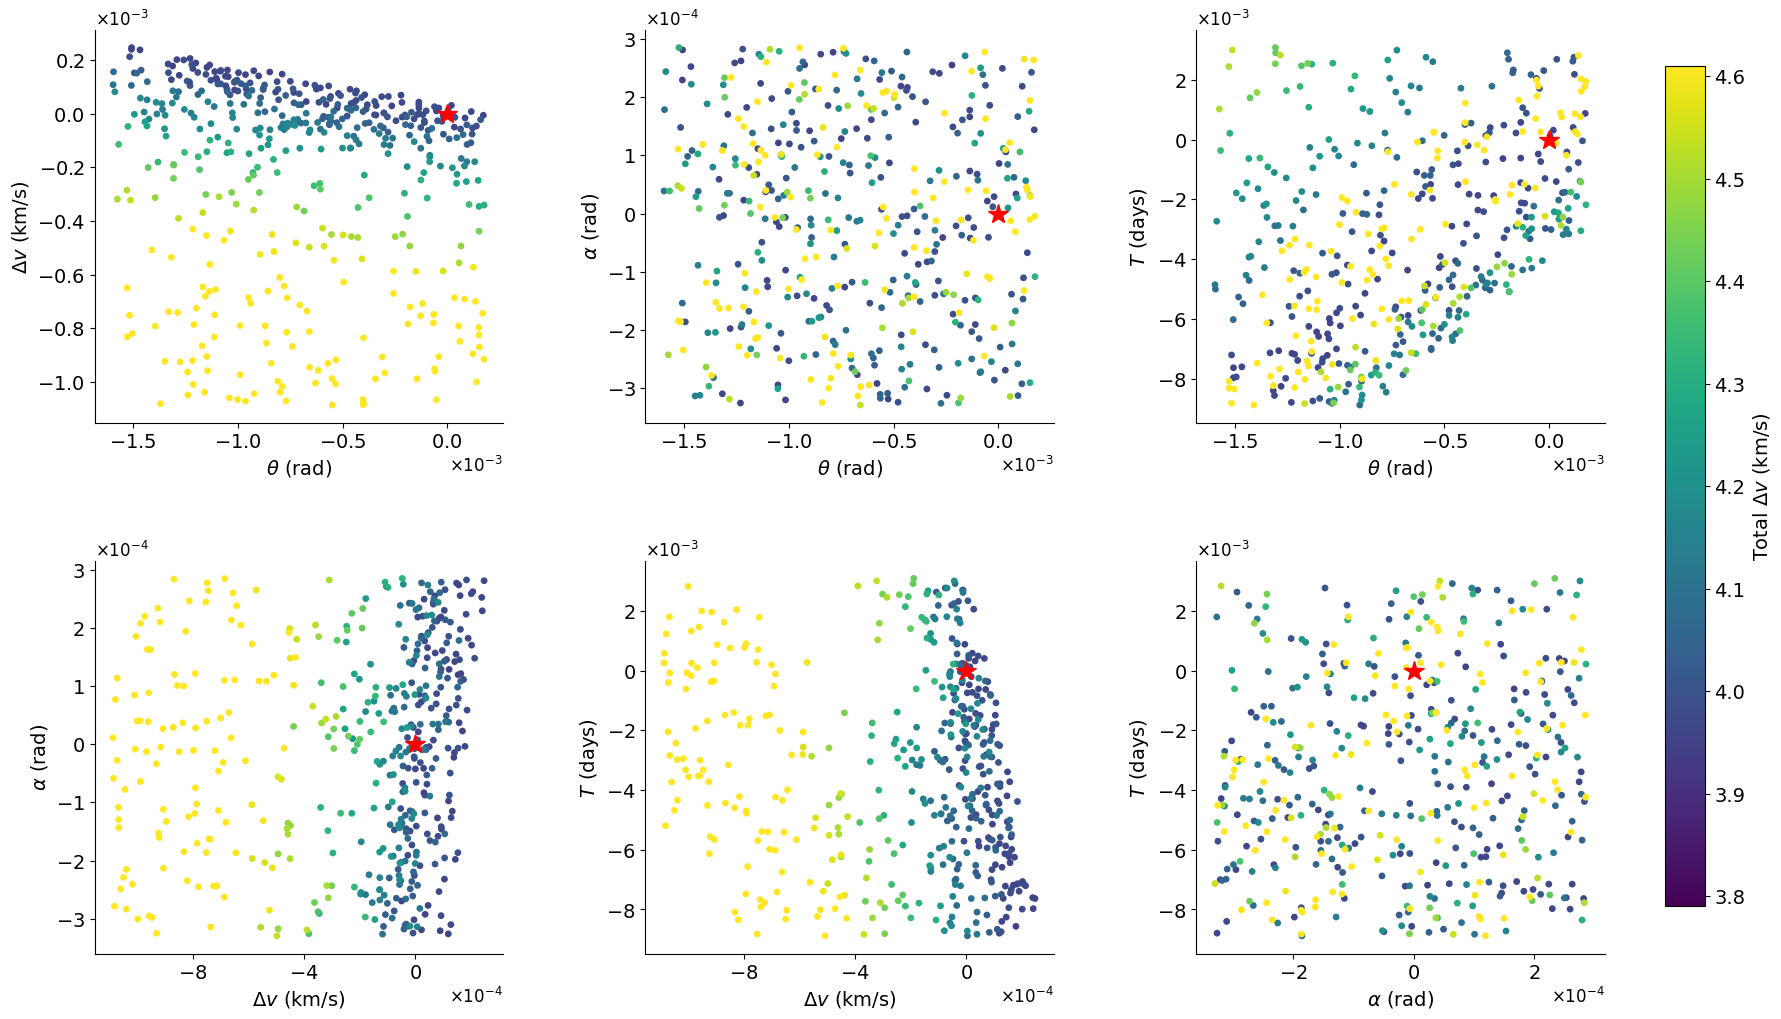

In [8]:
optimal, fig = analyse_sweep(results, em)

#### Plotting

In [23]:
from itertools import combinations

def analyse_sweep_filtered(results_df, cr3bp, fontsize=14):
    """
    Filter the delta_v values to only include those within 5% of the optimal, then
    plot all 6 pairwise 2D scatter slices through the 4D parameter space.

    Values are converted to dimensional units and plotted relative to the
    optimal solution.

    Parameters
    ----------
    results_df : pd.DataFrame
        Output from parameter_sweep. Must contain columns:
        theta, delta_v, delta_v_angle, tof, total_delta_v, distance_to_lmo.
        All values in normalised CR3BP units.
    cr3bp : object
        CR3BP system object with attributes l_star, t_star, v_star.
    fontsize : int, optional
        Font size for labels and ticks.

    Returns
    -------
    error_ranges : dict
        Dictionary with keys as variable names and values as (min, max) tuples
        of the dimensional range relative to the optimal solution.
    fig : matplotlib.figure.Figure
        The 2x3 subplot figure.
    """
    feasible = results_df.dropna(subset=['total_delta_v']).copy()
    feasible = feasible[feasible['total_delta_v'] < 1.05 * feasible['total_delta_v'].min()]

    if feasible.empty:
        print("No feasible solutions found in sweep.")
        return None, None

    optimal_idx = feasible['total_delta_v'].idxmin()
    optimal_row = feasible.loc[optimal_idx]

    var_names = ['theta', 'delta_v', 'delta_v_angle', 'tof']
    var_config = {
        'theta':         {'symbol': r'$\theta$',      'unit': 'rad',  'scale': 1.0},
        'delta_v':       {'symbol': r'$\Delta v$',    'unit': 'km/s', 'scale': cr3bp.v_star * 1e-3},
        'delta_v_angle': {'symbol': r'$\alpha$',      'unit': 'rad',  'scale': 1.0},
        'tof':           {'symbol': r'$T$',           'unit': 'days', 'scale': cr3bp.t_star / 86400},
    }

    pairs = list(combinations(var_names, 2))

    # Compute error ranges
    error_ranges = {}
    for var in var_names:
        cfg = var_config[var]
        offsets = (feasible[var] - optimal_row[var]) * cfg['scale']
        error_ranges[var] = (offsets.min(), offsets.max())

    # For each variable, find which panel index shows the largest range
    # and whether it appears as x-axis or y-axis on that panel
    best_panel = {}  # var -> (panel_index, 'x' or 'y')
    for var in var_names:
        max_range = -1
        for i, (var1, var2) in enumerate(pairs):
            if var == var1:
                r = error_ranges[var2][1] - error_ranges[var2][0]
                if r > max_range:
                    max_range = r
                    best_panel[var] = (i, 'x')
            elif var == var2:
                r = error_ranges[var1][1] - error_ranges[var1][0]
                if r > max_range:
                    max_range = r
                    best_panel[var] = (i, 'y')

    # Plotting
    dv_scale = cr3bp.v_star * 1e-3
    vmin = 3.7 * dv_scale
    vmax = 4.5 * dv_scale

    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    axes = axes.flatten()

    for i, (var1, var2) in enumerate(pairs):
        ax = axes[i]
        cfg1 = var_config[var1]
        cfg2 = var_config[var2]

        x = (feasible[var1] - optimal_row[var1]) * cfg1['scale']
        y = (feasible[var2] - optimal_row[var2]) * cfg2['scale']

        ax.scatter(x, y, c='black', vmin=vmin, vmax=vmax, s=15)
        ax.plot(0, 0, 'r*', markersize=15)

        # Draw range lines only on the best panel for each variable
        if best_panel[var1] == (i, 'x'):
            ax.axvline(error_ranges[var1][0], color='red', linestyle='--', linewidth=1.2)
            ax.axvline(error_ranges[var1][1], color='red', linestyle='--', linewidth=1.2)

        if best_panel[var2] == (i, 'y'):
            ax.axhline(error_ranges[var2][0], color='red', linestyle='--', linewidth=1.2)
            ax.axhline(error_ranges[var2][1], color='red', linestyle='--', linewidth=1.2)

        ax.set_xlabel(f"{cfg1['symbol']} ({cfg1['unit']})", fontsize=fontsize)
        ax.set_ylabel(f"{cfg2['symbol']} ({cfg2['unit']})", fontsize=fontsize)
        ax.tick_params(labelsize=fontsize)
        ax.xaxis.set_major_locator(plt.MaxNLocator(4))
        ax.ticklabel_format(style='scientific', scilimits=(0, 0), useMathText=True)
        ax.xaxis.get_offset_text().set_fontsize(fontsize - 2)
        ax.yaxis.get_offset_text().set_fontsize(fontsize - 2)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

    return error_ranges, fig

#### Plot

C:\Users\scoul\AppData\Local\Temp\ipykernel_24652\2027695956.py:90: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(x, y, c='black', vmin=vmin, vmax=vmax, s=15)


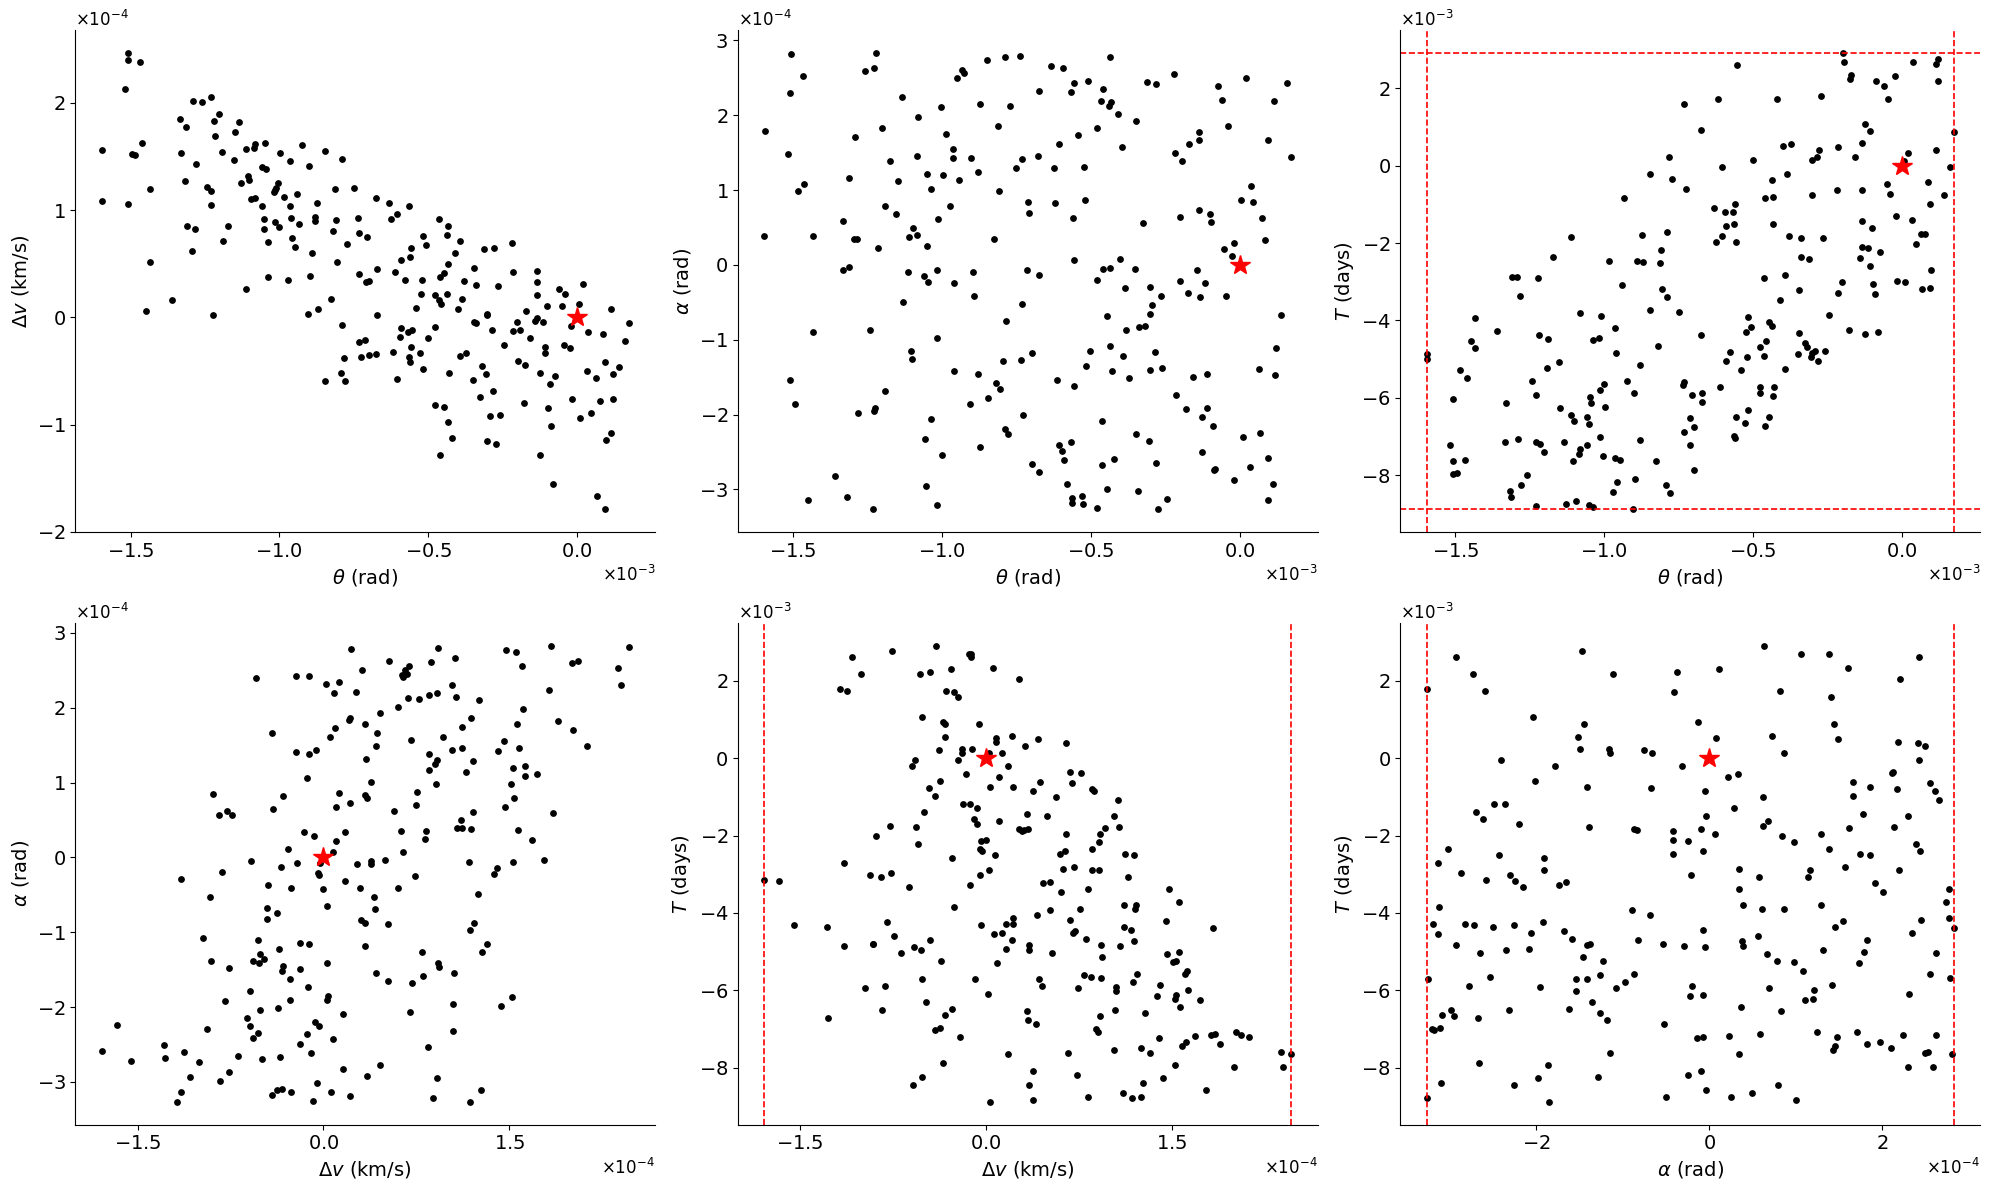

In [ ]:
error_results, fig2 = analyse_sweep_filtered(results, em)

In [15]:
optimal2['total_delta_v'] * 1.05

np.float64(4.055846191839095)